This is the final version of the model that generates the heatmap as the result in the repository it is called: V2_run_batch02.ipynb

The full repository with all the versions and updates to the code can be found at: https://github.com/danielkoni/Modelling-AI-Usage

The line plot code for the top and bottom 20% of agents can be found at the end of the V2_run_batch01.ipynb file.


### Introduction
This project aims to explore how AI induced skill decay manifest in a complex social environment. Using the Agent based modelling Mesa Python library we run a model where agents interact and compete on tasks and by doing so change your skill level. There are also given the option to use a performance enhancing option that we call AI skill level.

In [79]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mesa
import pandas as pd

from mesa.visualization import SolaraViz, make_plot_component, make_space_component

In [ ]:
def update_expectation(expected_outcome, outcome, alpha):
    expected_outcome += alpha * (outcome - expected_outcome)
    return expected_outcome
"""This function enacts the Rescorla-Wagner rule, where with every step the agent can
reinforce their position on whether to use AI or not in the next step"""


class AdoptionAgent(mesa.Agent):
    """An agent with skill, and the ability to choose to use artificial intelligence tools,
    that can compete to complete a task if it meets another agent"""

    def __init__(self, model):
        """initialize an AdoptionAgent instance.

        Args:
            model: A model instance

            self.skill: Is a normally distributed set skill level between 0 and 1 that can increase by
            succesfully winning at tasks without using AI or decrease by using AI

            self.ability: Is a combination of skill, luck and AI usage between 0 and 1 that
            is the metric used to see who wins in a 'compete' instance.

            self.wins: Is a value that counts the amount of times the chosen agent won.

            self.losses: Counts the losses.

            self.aichoice: Is the outcome of their decision to either use or not use AI, either a 0 or a 1 respectively.

            self.expected: Is the leaning of an agent towards using or not using AI.

            self.evidence: Is the outcome of the competition that suggests if using AI was useful or not.
            If they won without using AI evidence will be set to 0, if they lost and used AI it will also be set to 0.
            If they lost simply then it will be set to 1 and if they won using AI it will also be set to 1.
            This value sets the direction for the update_expectation function.
        """
        super().__init__(model)
        
        "Preset starting variables for the model:"
        self.skill = np.clip(np.random.normal(loc=0.5, scale=0.1), 0, 1)
        self.ability = 0
        self.wins = 1
        self.losses = 1
        self.aichoice = 0
        self.expected = 0.5
        self.evidence = 0
        self.luck = 0

        """Variables that can be changed between batches:
        Alpha (float, set at 0.05): This value represents the learning rate for an agent’s skill updates, the higher it is the faster the agent adapts to new information.
        Beta (float, set at 0.01): The rate of skill increase or decay when an agent competes it represents the cost of not sustaining a skill or the gain of developing a skill.
        AISkillLevel (float, range 0 to 1): The ability level that is set to the agent during a competition if the agent decides to use AI assistance.
        Middle (float, set at 0.10): The middle value sets the centre of the random normal distribution from which the luck value is generated for each agent at each competition instance
        Scaler (float, set at 0.02): The Scaler value represents the standard deviation of the normal distribution from which the luck value is generated for each agent at each competition instance
        """
        self.alpha = 0.05
        self.beta = 0.01
        self.AISkillLevel = self.model.AISkillLevel
        self.middle = 0.10
        self.scaler = 0.02
        


    def move(self):
        """Move to a random neighboring cell."""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def compete(self):
        """One agent picks another agent on its spot, they both decide if they want to use AI, they both set new luck variables,
         they calcualte their ability AI or not, since ability is already calculated for the match they update their skill, then they compete and update their expected
          values and win/loss values."""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        if len(cellmates) > 1:
            other = self.random.choice(cellmates)


            self.aichoice = np.random.choice([0, 1], p=[1 - self.expected, self.expected])
            other.aichoice = np.random.choice([0, 1], p=[1 - other.expected, other.expected])

            self.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)
            other.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)

            self.ability = np.clip((self.skill + self.luck) * (1 - self.aichoice) + (self.AISkillLevel * self.aichoice), 0, 1)
            other.ability = np.clip((other.skill + other.luck) * (1 - other.aichoice) + (other.AISkillLevel * other.aichoice), 0, 1)
            self.skill = np.clip(self.skill + ((-1)**self.aichoice ) * self.beta, 0, 1)
            if self.ability > other.ability:
                self.wins += 1
                self.evidence = 1 * self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, self.alpha)

            else:
                self.losses += 1
                self.evidence = 1 - self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, self.alpha)




    def step(self):
        """do one step of the agent."""
        self.move()
        self.compete()


class AdoptionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self,
                 alpha = 0.05,
                 beta = 0.01,
                 AISkillLevel = 0.1,
                 middle = 0.05,
                 scaler = 0.02,
                 n=80,
                 width=10,
                 height=10,
                 seed=None):
        
        """Initialize a competition instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
            and other variables mentioned above.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        self.alpha = alpha
        self.beta = beta
        self.AISkillLevel = AISkillLevel
        self.middle = middle
        self.scaler = scaler
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        agents = AdoptionAgent.create_agents(model=self, n=n)
        # Create x and y positions for agents
        x = self.rng.integers(0, self.grid.width, size=(n,))
        y = self.rng.integers(0, self.grid.height, size=(n,))
        for a, i, j in zip(agents, x, y):
            # Add the agent to a random grid cell
            self.grid.place_agent(a, (i, j))

        """Data collector saves all the new information at every step of the model."""
        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "Skill": "skill",
                "Ability": "ability",
                "Wins": "wins",
                "Losses": "losses",
                "AI Usage Choice": "aichoice",
                "Expected": "expected",
                "Evidence": "evidence",
                "Luck" : "luck",
                "AI Skill Level" : "AISkillLevel"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

In [ ]:
"""This cell allows to run the model across different runs called batch_run."""
params = {
          "AISkillLevel": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99],
          }

results = mesa.batch_run(
    AdoptionModel,
    parameters=params,
    iterations=1,
    max_steps=10000,
    number_processes=1,
    data_collection_period=1,
    display_progress=True,
)


df = pd.DataFrame(results)
print(df.keys())

  0%|          | 0/10 [00:00<?, ?it/s]

Index(['RunId', 'iteration', 'Step', 'AISkillLevel', 'AgentID', 'Skill',
       'Ability', 'Wins', 'Losses', 'AI Usage Choice', 'Expected', 'Evidence',
       'Luck', 'AI Skill Level'],
      dtype='object')


In [82]:
df

,RunId,iteration,Step,AISkillLevel,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Evidence,Luck,AI Skill Level
0,0,0,0,0.10,1,0.601119,0.000000,1,1,0,0.500000,0,0.000000,0.10
1,0,0,0,0.10,2,0.438563,0.000000,1,1,0,0.500000,0,0.000000,0.10
2,0,0,0,0.10,3,0.326126,0.000000,1,1,0,0.500000,0,0.000000,0.10
3,0,0,0,0.10,4,0.397723,0.000000,1,1,0,0.500000,0,0.000000,0.10
4,0,0,0,0.10,5,0.655489,0.000000,1,1,0,0.500000,0,0.000000,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8000795,9,0,10000,0.99,76,0.120000,0.232330,1016,4450,0,0.508287,0,0.112330,0.99
8000796,9,0,10000,0.99,77,0.010000,0.990000,959,4511,1,0.619788,0,0.104457,0.99
8000797,9,0,10000,0.99,78,0.070000,0.162366,995,4503,0,0.576110,1,0.102366,0.99
8000798,9,0,10000,0.99,79,0.060000,0.990000,976,4536,1,0.658622,1,0.050703,0.99


In [ ]:
step1 = df[(df['RunId'] == 0) & (df['Step'] == 0)]

#Created a dictionary to store quantile thresholds of the first step
thresholds = {}

for i in range(1, 11):  # i from 1 to 10
    q = i / 10
    thresholds[q] = step1['Skill'].quantile(q)

thresholds

{0.1: np.float64(0.39018148702340605),
 0.2: np.float64(0.4330785259704195),
 0.3: np.float64(0.45480390198143844),
 0.4: np.float64(0.4768279171036687),
 0.5: np.float64(0.4995690753171912),
 0.6: np.float64(0.5185556064905157),
 0.7: np.float64(0.5504517175857631),
 0.8: np.float64(0.5805773410553527),
 0.9: np.float64(0.6063980136504187),
 1.0: np.float64(0.6554888924465405)}

In [ ]:
#Test code for getting all of the quantile ids by looping the lower and higher value like 0 to 10, 10 to 20 etc.
ids_quantile_ranges = {}
quantiles = [i / 10 for i in range(11)]  # [0.0, 0.1, ..., 1.0]

for i in range(1, len(quantiles)):
    q_low = quantiles[i - 1]
    q_high = quantiles[i]
    
    low_thresh = step1['Skill'].quantile(q_low)
    high_thresh = step1['Skill'].quantile(q_high)
    
    label = f"q{int(q_low*100)}_to_q{int(q_high*100)}"
    agent_ids = step1[(step1['Skill'] > low_thresh) & (step1['Skill'] <= high_thresh)]['AgentID']
    ids_quantile_ranges[label] = agent_ids.tolist()

ids_quantile_ranges

{'q0_to_q10': [3, 36, 46, 53, 71, 74, 77],
 'q10_to_q20': [4, 9, 21, 22, 24, 63, 72, 76],
 'q20_to_q30': [2, 12, 20, 47, 55, 61, 70, 75],
 'q30_to_q40': [8, 23, 29, 32, 37, 45, 51, 67],
 'q40_to_q50': [7, 28, 33, 41, 44, 52, 62, 68],
 'q50_to_q60': [10, 14, 25, 48, 58, 60, 65, 69],
 'q60_to_q70': [13, 17, 27, 30, 31, 42, 49, 66],
 'q70_to_q80': [11, 16, 38, 43, 54, 56, 59, 80],
 'q80_to_q90': [1, 6, 18, 19, 35, 50, 73, 78],
 'q90_to_q100': [5, 15, 26, 34, 39, 40, 57, 79]}

In [ ]:
#Test code for running a for loop to grab the avg skills at step 0 and step 10000 per quantile

hello = []

for label, ids in ids_quantile_ranges.items():
    df_group = df[(df['RunId'] == 0) & (df['AgentID'].isin(ids))]
    
    step0_avg = df_group[df_group['Step'] == 0]['Skill'].mean()
    step_max_val = df_group['Step'].max()
    step_max_avg = df_group[df_group['Step'] == step_max_val]['Skill'].mean()
    
    hello.append({
        'Quantile Range': label,
        'Step 0 Avg Skill': step0_avg,
        f'Step {step_max_val} Avg Skill': step_max_avg
    })

hello_df = pd.DataFrame(hello)
hello_df

,Quantile Range,Step 0 Avg Skill,Step 10000 Avg Skill
0,q0_to_q10,0.337252,0.978571
1,q10_to_q20,0.406100,0.975000
2,q20_to_q30,0.441337,0.978750
3,q30_to_q40,0.463739,0.990000
4,q40_to_q50,0.488941,0.967500
5,q50_to_q60,0.511420,0.970000
6,q60_to_q70,0.537125,0.985000
7,q70_to_q80,0.568559,0.985000
8,q80_to_q90,0.599694,0.992500
9,q90_to_q100,0.630749,0.992500


In [ ]:
#Applying both of the above test code cells but for all the runs in a single loop

import pandas as pd

all_results = []

for run_id in range(10):
    step0 = df[(df['RunId'] == run_id) & (df['Step'] == 0)]
    
    quantiles = [i / 10 for i in range(11)]
    
    for i in range(1, len(quantiles)):
        q_low = quantiles[i - 1]
        q_high = quantiles[i]
        
        #Computing that threshold
        low_thresh = step0['Skill'].quantile(q_low)
        high_thresh = step0['Skill'].quantile(q_high)
        
        #Getting agents into their quantile bins
        agent_ids = step0[(step0['Skill'] > low_thresh) & (step0['Skill'] <= high_thresh)]['AgentID']
        
        #Filtering full df for these agents at the current run
        df_group = df[(df['RunId'] == run_id) & (df['AgentID'].isin(agent_ids))]
        
        step0_avg = df_group[df_group['Step'] == 0]['Skill'].mean()
        step1000_avg = df_group[df_group['Step'] == 10000]['Skill'].mean()
        skill_gain = step1000_avg - step0_avg
        
        #Appending our results
        all_results.append({
            'AISkillLevel': run_id * 0.1 + 0.1,
            'Quantile': f'q{int(q_low*100)}_to_q{int(q_high*100)}',
            'Step0Avg': step0_avg,
            'Step1000Avg': step1000_avg,
            'SkillGain': skill_gain
        })


results_df = pd.DataFrame(all_results)

In [ ]:
#Calculating Step0Avg for each quantile across all runs
quantile_averages = results_df.groupby('Quantile')['Step0Avg'].mean()

#Mapping it and adding to my df
quantile_avg_dict = quantile_averages.to_dict()
results_df['QuantileAvgStep0'] = results_df['Quantile'].map(quantile_avg_dict)

print(results_df.head(15)) 

    AISkillLevel     Quantile  Step0Avg  Step1000Avg  SkillGain  \
0            0.1    q0_to_q10  0.337252     0.978571   0.641320   
1            0.1   q10_to_q20  0.406100     0.975000   0.568900   
2            0.1   q20_to_q30  0.441337     0.978750   0.537413   
3            0.1   q30_to_q40  0.463739     0.990000   0.526261   
4            0.1   q40_to_q50  0.488941     0.967500   0.478559   
5            0.1   q50_to_q60  0.511420     0.970000   0.458580   
6            0.1   q60_to_q70  0.537125     0.985000   0.447875   
7            0.1   q70_to_q80  0.568559     0.985000   0.416441   
8            0.1   q80_to_q90  0.599694     0.992500   0.392806   
9            0.1  q90_to_q100  0.630749     0.992500   0.361751   
10           0.2    q0_to_q10  0.341904     0.971429   0.629524   
11           0.2   q10_to_q20  0.395551     0.987500   0.591949   
12           0.2   q20_to_q30  0.432699     0.977500   0.544801   
13           0.2   q30_to_q40  0.465112     0.980000   0.51488

In [ ]:
#Since the highest AISkill value is 0.99 I am renaming the last value to 0.99
results_df['AISkillLevel'] = results_df['AISkillLevel'].replace(1.0, 0.99)
results_df.head(-10)
results_df['AISkillLevel']

0     0.10
1     0.10
2     0.10
3     0.10
4     0.10
      ... 
95    0.99
96    0.99
97    0.99
98    0.99
99    0.99
Name: AISkillLevel, Length: 100, dtype: float64

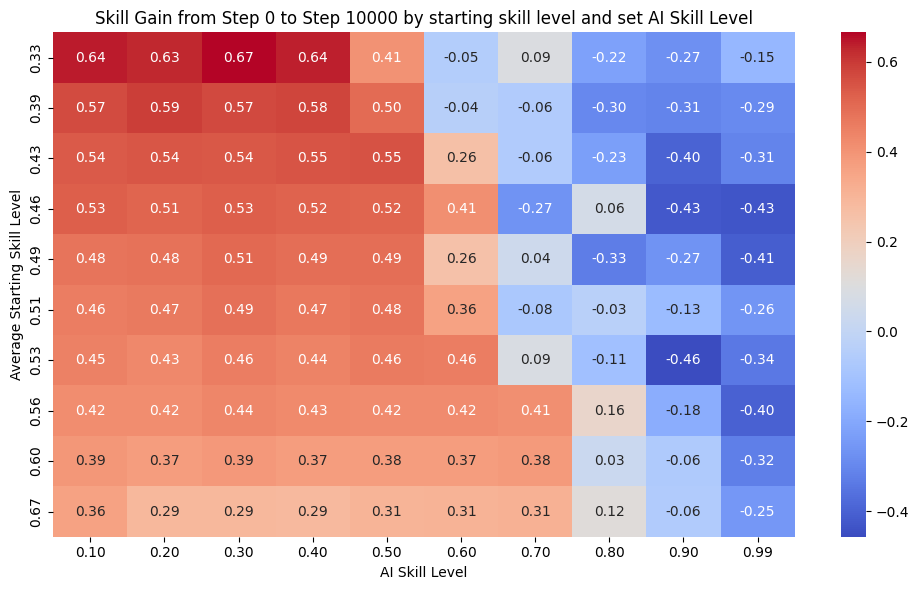

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


pivot = results_df.pivot(index='QuantileAvgStep0', columns='AISkillLevel', values='SkillGain')

#Nifty code to match decimal places
y_labels = [f"{val:.2f}" for val in pivot.index] 
x_labels = [f"{val:.2f}" for val in pivot.columns]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='coolwarm',
            yticklabels=y_labels, xticklabels=x_labels)
plt.title('Skill Gain from Step 0 to Step 10000 by starting skill level and set AI Skill Level')
plt.ylabel('Average Starting Skill Level')
plt.xlabel('AI Skill Level')

plt.tight_layout()
plt.show()